# Soil Organic Carbon Dataset Download

In [1]:
import ee

ee.Authenticate()
ee.Initialize()

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geemap as gm

sns.set_theme(style="whitegrid")
sns.set_context("talk")

# Import Local Data
Get all data that is alredy downloaded.

## Point Shapefile

In [3]:
path_to_soc_shp = './data/sichei_attr.shp'
path_to_soc_csv = './data/sichei_attr.csv'

# Load the shapefile
soc_gdf = gpd.read_file(path_to_soc_shp)

print(f'Columns GDF \n {soc_gdf.columns}')
print(f'Number of rows: {soc_gdf.shape[0]}')

soc = pd.read_csv(path_to_soc_csv)
print(f'Columns DF \n {soc.columns}')
print(f'Number of rows: {soc.shape[0]}')

soc.head()

Columns GDF 
 Index(['Site', 'Cluster', 'Plot', 'Depthcode', 'predSOC', 'Date', 'Latitude',
       'Longitude', 'Altitude', 'geometry'],
      dtype='object')
Number of rows: 319
Columns DF 
 Index(['Site', 'Cluster', 'Plot', 'Depthcode', 'predSOC', 'Date', 'Latitude',
       'Longitude', 'Altitude'],
      dtype='object')
Number of rows: 319


,Site,Cluster,Plot,Depthcode,predSOC,Date,Latitude,Longitude,Altitude
0,Sichei,1.0,1.0,Topsoil,11.246,10-Mar-21,0.711449,34.6406,1544.81
1,Sichei,1.0,1.0,Subsoil,8.619,10-Mar-21,0.711449,34.6406,1544.81
2,Sichei,2.0,1.0,Topsoil,11.516,11-Mar-21,0.731318,34.6339,1552.42
3,Sichei,2.0,1.0,Subsoil,9.866,11-Mar-21,0.731318,34.6339,1552.42
4,Sichei,3.0,1.0,Topsoil,14.464,12-Mar-21,0.768700,34.6443,1611.33


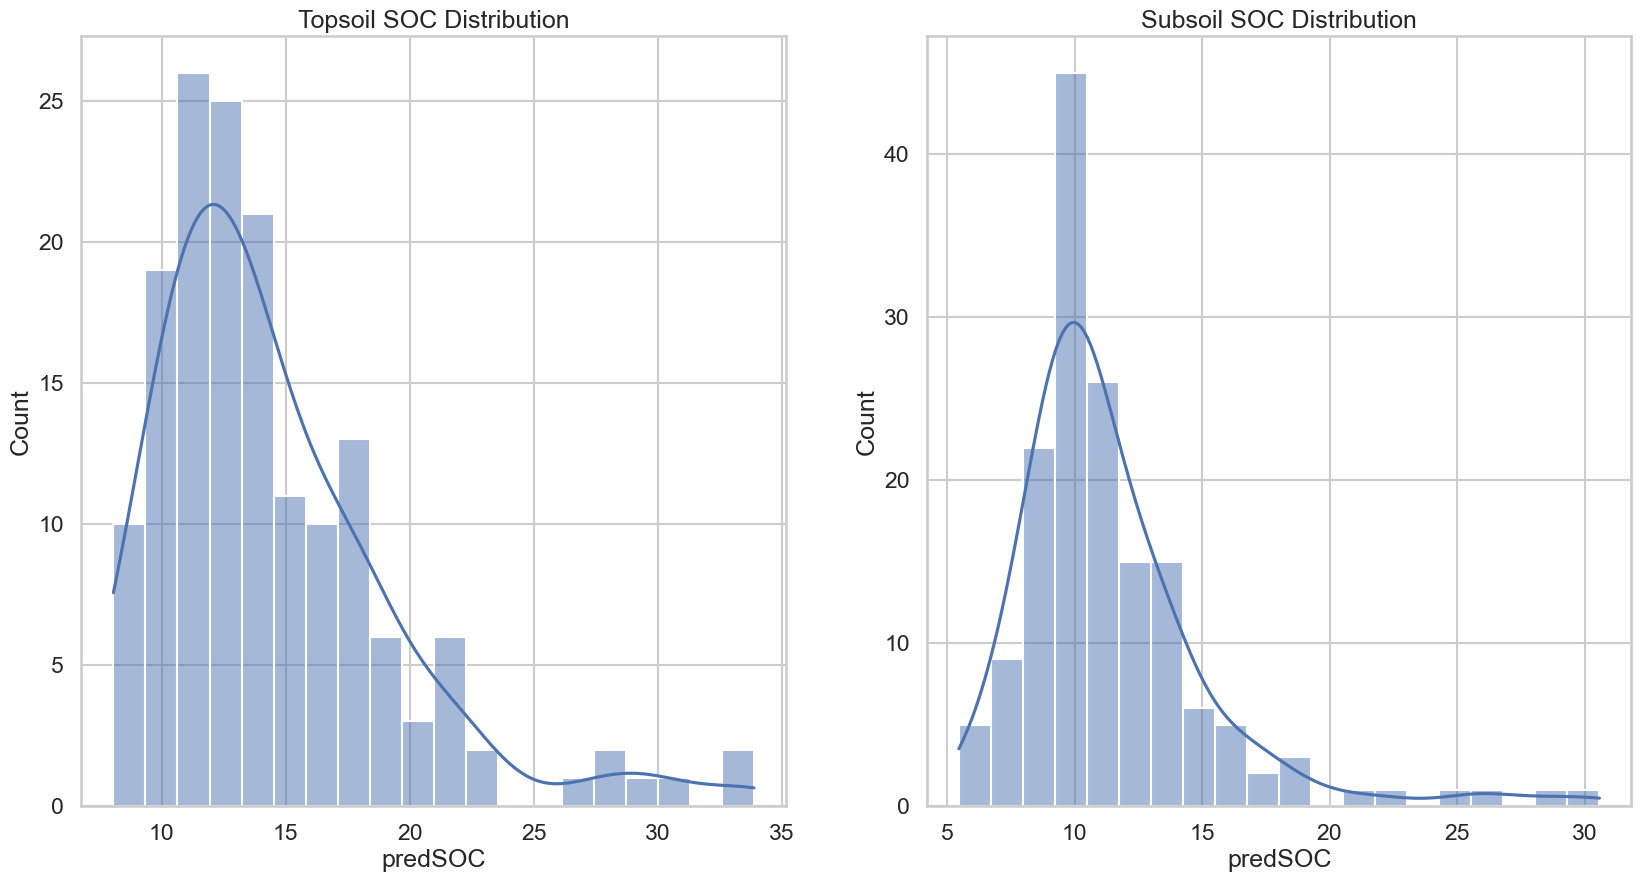

In [4]:
# Split into top and subsoil
topsoil = soc[soc['Depthcode'] == 'Topsoil']
subsoil = soc[soc['Depthcode'] == 'Subsoil']

# Plot the data
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

sns.histplot(topsoil['predSOC'], bins=20, kde=True, ax=ax[0])
ax[0].set_title('Topsoil SOC Distribution')

sns.histplot(subsoil['predSOC'], bins=20, kde=True, ax=ax[1])
ax[1].set_title('Subsoil SOC Distribution')

plt.show()

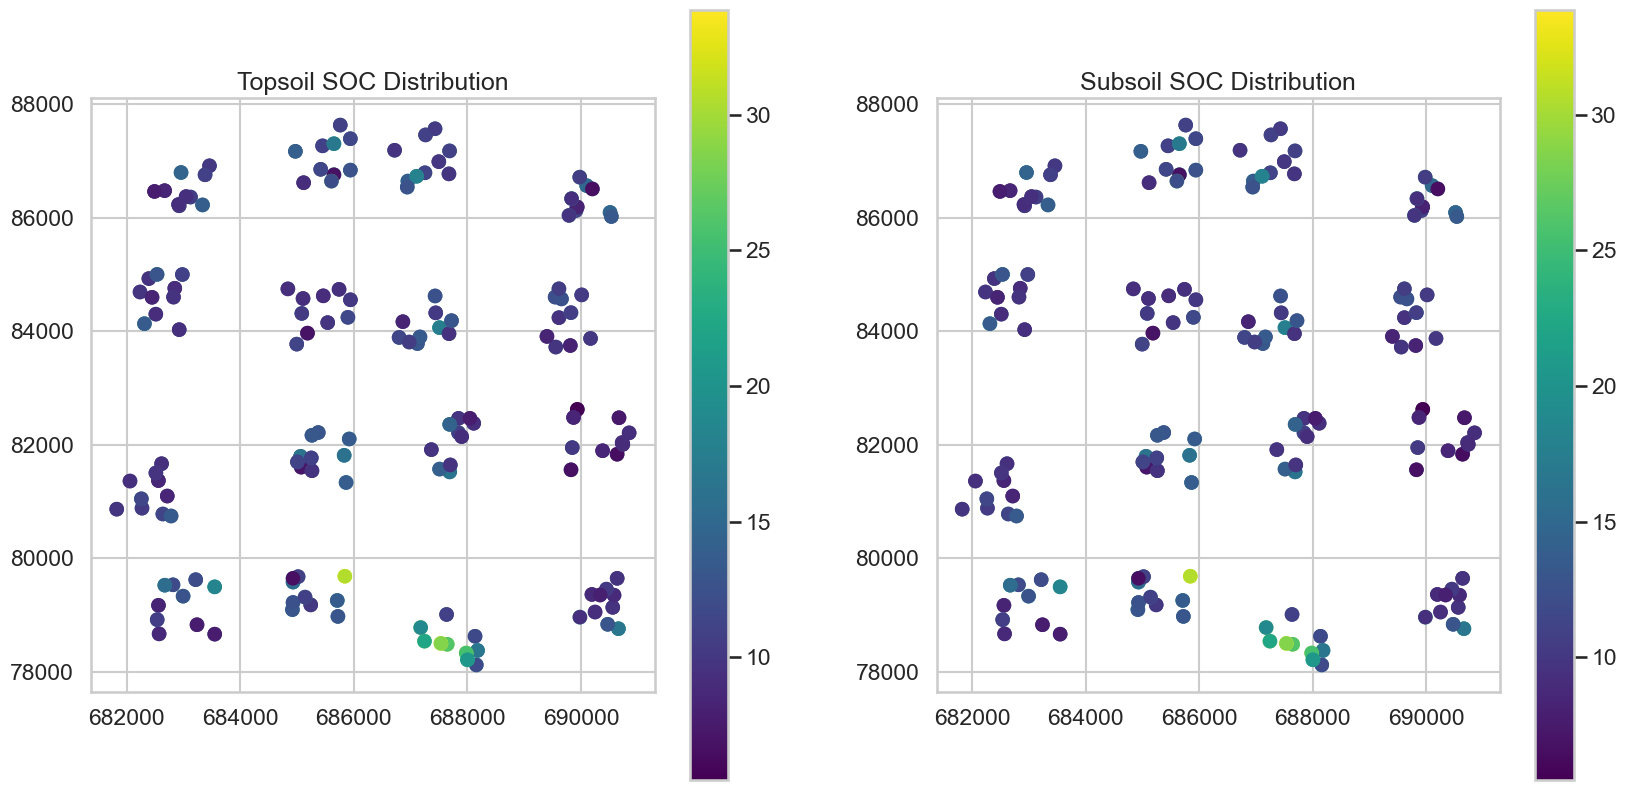

In [5]:
# Spatial Plot
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

soc_gdf.plot(column='predSOC', cmap='viridis', legend=True, ax=ax[0])
ax[0].set_title('Topsoil SOC Distribution')

soc_gdf.plot(column='predSOC', cmap='viridis', legend=True, ax=ax[1])
ax[1].set_title('Subsoil SOC Distribution')

plt.show()



## The Bounding of the Data

Since I shall be getting data from Google Earth Engine using the python API, it is important to describe the bounding box of the dataset. 
This will be achieved by describing the extent of the data then, provinding a buffer of 2km around the extent. The resulting polygon will then be exported as the `bbox` of the region of study

In [6]:
soc_gdf.crs.to_epsg()

32636

In [7]:
from shapely.geometry import box
xmin, ymin, xmax, ymax = soc_gdf.total_bounds
bbox = box(xmin, ymin, xmax, ymax)
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox], crs=soc_gdf.crs)
buffered_bbox_gdf = bbox_gdf.buffer(1000)
buffered_bbox_gdf = gpd.GeoDataFrame(geometry=buffered_bbox_gdf, crs=soc_gdf.crs)

# COnvert the bounding box to ee.Geometry
bbox_ee = gm.geopandas_to_ee(buffered_bbox_gdf)

buffered_bbox_gdf.to_file("./data/bbox.shp", driver='ESRI Shapefile')

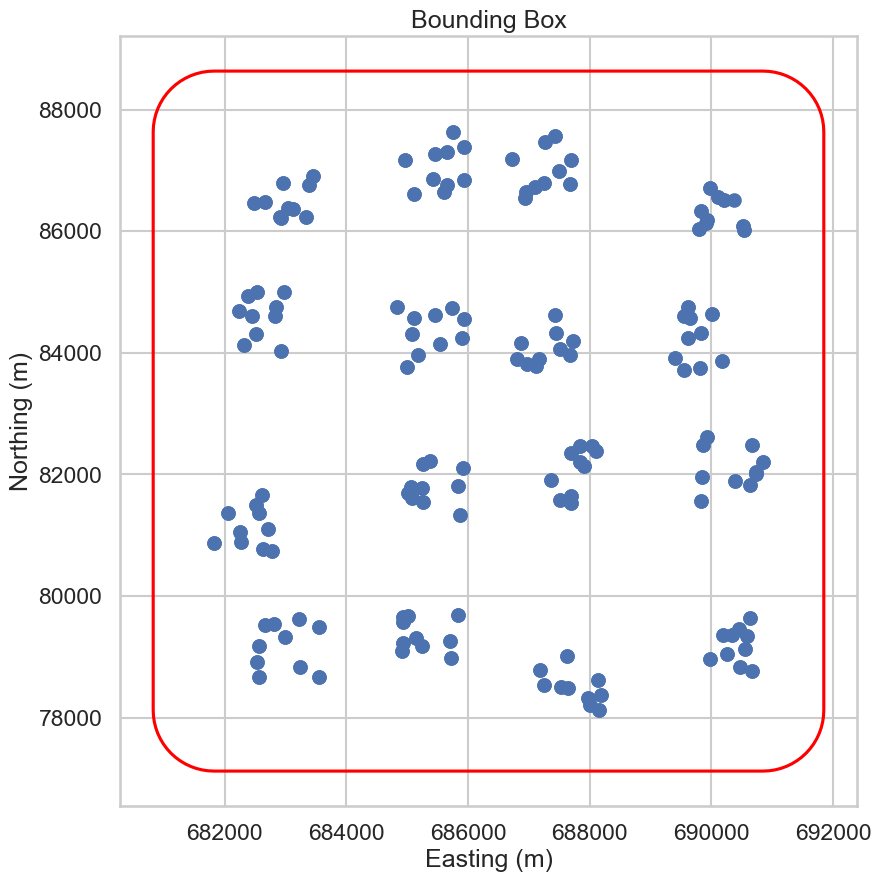

In [8]:
# Plot the bbox
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=100)
soc_gdf.plot(ax=ax)
buffered_bbox_gdf.boundary.plot(ax=ax, color='red')
plt.title('Bounding Box')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)') 
plt.show()

## Datasets from Google Earth Engine
Data from Google Earth Engine for Predicting Soil Organic Carbon.  
The following datasets will be used in the study:
- Sentinel-1
- Sentinel-2
- Land Use Land Cover
- WAPOR Evapotranspiration
- 

### Sentinel 1 RADAR Data 
Collection of SAR data from the COPERNICUS collection

In [30]:
def mask_edge(image):
    edge = image.lt(-30.0)
    masked_image = image.mask().And(edge.Not())
    return image.updateMask(masked_image)

In [ ]:
img_vv_vh = (
    ee.ImageCollection('COPERNICUS/S1_GRD')
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .select(['VV','VH'])  
    .map(mask_edge)
)

focus_date = ee.Filter.date('2021-03-01', '2021-03-20')
img_mean = img_vv_vh.filter(focus_date).mean().clip(bbox_ee)

In [31]:
sarMap = gm.Map()
sarMap.center_object(bbox_ee, 12)
sarMap.add_layer(img_mean, {'min': -25, 'max': 5}, 'Multi-T Mean ASC', True)
sarMap

Map(center=[0.7494919277365318, 34.67445436967993], controls=(WidgetControl(options=['position', 'transparent_…

In [57]:
# Sample the data from the image using the points from the shapefile
soc_points = gm.geopandas_to_ee(soc_gdf)

socsoil_points = img_mean.sampleRegions(
    collection=soc_points,
    scale=10,
    geometries=True
)

### Sentinel 2 MSI Data


In [60]:
def mask_s2_clouds(image):
    """Masks clouds in a Sentinel-2 image using the QA band.

    Args:
        image (ee.Image): A Sentinel-2 image.

    Returns:
        ee.Image: A cloud-masked Sentinel-2 image.
    """
    qa = image.select('QA60')

    # Bits 10 and 11 are clouds and cirrus, respectively.
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11

    # Both flags should be set to zero, indicating clear conditions.
    mask = (
        qa.bitwiseAnd(cloud_bit_mask)
        .eq(0)
        .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    )

    return image.updateMask(mask).divide(10000)


dataset = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2021-03-01', '2021-04-01')
    # Pre-filter to get less cloudy granules.
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .map(mask_s2_clouds)
    .select(['B2', 'B3', 'B4','B5','B6','B7','B8', 'B8A','B9', 'B11', 'B12']) 
    .mean().clip(bbox_ee)
)

visualization = {
    'min': 0.0,
    'max': 0.3,
    'bands': ['B4', 'B3', 'B2'],
}

m = gm.Map()
m.center_object(bbox_ee, 12)
m.add_layer(dataset, visualization, 'RGB')
m

Map(center=[0.7494919277365318, 34.67445436967993], controls=(WidgetControl(options=['position', 'transparent_…

In [63]:
# Sample the data from the image using the points from the shapefile
socsoil_points = dataset.sampleRegions(
    collection=socsoil_points,
    scale=10,
    geometries=True
)

soilpoints = gm.ee_to_gdf(socsoil_points)
soilpoints.head()

,geometry,Altitude,B11,B12,B2,B3,B4,B5,B6,B7,...,Cluster,Date,Depthcode,Latitude,Longitude,Plot,Site,VH,VV,predSOC
0,POINT (34.64061 0.71142),1544.81,0.290867,0.197833,0.048367,0.081767,0.088233,0.136800,0.224033,0.2534,...,1,10-Mar-21,Topsoil,0.711449,34.6406,1,Sichei,-17.836760,-12.758419,11.246
1,POINT (34.64061 0.71142),1544.81,0.290867,0.197833,0.048367,0.081767,0.088233,0.136800,0.224033,0.2534,...,1,10-Mar-21,Subsoil,0.711449,34.6406,1,Sichei,-17.836760,-12.758419,8.619
2,POINT (34.63387 0.73127),1552.42,0.283067,0.224800,0.048400,0.077333,0.112133,0.144200,0.175300,0.1972,...,2,11-Mar-21,Topsoil,0.731318,34.6339,1,Sichei,-17.730830,-10.699263,11.516
3,POINT (34.63387 0.73127),1552.42,0.283067,0.224800,0.048400,0.077333,0.112133,0.144200,0.175300,0.1972,...,2,11-Mar-21,Subsoil,0.731318,34.6339,1,Sichei,-17.730830,-10.699263,9.866
4,POINT (34.64429 0.76873),1611.33,0.289133,0.193467,0.046633,0.078833,0.084133,0.130167,0.256433,0.3019,...,3,12-Mar-21,Topsoil,0.768700,34.6443,1,Sichei,-15.203887,-10.196469,14.464


In [64]:
soilpoints.columns

Index(['geometry', 'Altitude', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6',
       'B7', 'B8', 'B8A', 'B9', 'Cluster', 'Date', 'Depthcode', 'Latitude',
       'Longitude', 'Plot', 'Site', 'VH', 'VV', 'predSOC'],
      dtype='object')

## Machine Learning

In [84]:
# Create a mean of the topspoil and subsoil values
soilpoints_avg = soilpoints.pivot_table(index=('Latitude', 'Longitude'), values=['Altitude', 'B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6',
    'B7', 'B8', 'B8A', 'B9', 'VH', 'VV','predSOC'], aggfunc='mean').reset_index()
soilpoints_gdf = gpd.GeoDataFrame(soilpoints_avg, geometry=gpd.points_from_xy(soilpoints_avg.Longitude, soilpoints_avg.Latitude), crs='EPSG:4326')

In [90]:
soilpoints_gdf.dropna(inplace=True)
predic = soilpoints_gdf['predSOC']
features = soilpoints_gdf.drop(columns=['predSOC', 'Latitude', 'Longitude', 'geometry'])

In [91]:
# Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, predic, test_size=0.2, random_state=42)


In [95]:
# Grid search of Random Forest, Gradient Boosting and SVM
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error as mse, mean_absolute_percentage_error as mape


In [ ]:

# Random Forest
rf = RandomForestRegressor()
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30]
}

rf_grid = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1)
rf_grid.fit(X_train, y_train)
print(f'Random Forest Best Parameters: {rf_grid.best_params_}')
print(f'Random Forest Best Score: {rf_grid.best_score_}')

# Gradient Boosting
gb = GradientBoostingRegressor()
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30]
}

gb_grid = GridSearchCV(gb, param_grid, cv=5, n_jobs=-1)
gb_grid.fit(X_train, y_train)
print(f'Gradient Boosting Best Parameters: {gb_grid.best_params_}')
print(f'Gradient Boosting Best Score: {gb_grid.best_score_}')

# SVM
svm = SVR()
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

svm_grid = GridSearchCV(svm, param_grid, cv=5, n_jobs=-1)
svm_grid.fit(X_train, y_train)
print(f'SVM Best Parameters: {svm_grid.best_params_}')
print(f'SVM Best Score: {svm_grid.best_score_}')

In [96]:
# Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=30)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mse = mse(y_test, rf_pred)
rf_mape = mape(y_test, rf_pred)
print(f'Random Forest MSE: {rf_mse}') 
print(f'Random Forest MAPE: {rf_mape}')

Random Forest MSE: 5.0372994168433305
Random Forest MAPE: 0.14465057661241387
